# CardioScope-XAI — SHAP Explainability
Generates global and per-patient SHAP explanations for the XGBoost model, making predictions interpretable for clinicians.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from src.data_loader import load_and_clean
from src.feature_engineering import build_feature_matrix
from src.xgboost_model import load_model as load_xgb
from src.explainability import (
    build_explainer, compute_shap_values,
    plot_summary, plot_waterfall, plot_bar,
    get_patient_explanation
)
import joblib

plt.rcParams['figure.dpi'] = 120
shap.initjs()

## 1. Load Data and Model

In [2]:
df      = load_and_clean('../data/raw/heart_disease_uci.csv')
scaler  = joblib.load('../models/scaler.pkl')
X, _    = build_feature_matrix(df, fit_scaler=False, scaler=scaler)
y       = df['target'].values
model   = load_xgb('../models/xgboost_model.pkl')

print(f'Feature matrix : {X.shape}')
print(f'XGBoost model  : loaded')

[data_loader] Using 'Cleveland' subset: 304 rows.
[data_loader] Dropped 7 rows with missing values.
[data_loader] Clean dataset: 297 rows, 14 columns.
[data_loader] Class balance — 0 (no disease): 160, 1 (disease): 137
[feature_engineering] Final feature matrix: 25 features, 297 samples.
Feature matrix : (297, 25)
XGBoost model  : loaded


## 2. Build SHAP Explainer and Compute Values

In [3]:
explainer   = build_explainer(model)
shap_values = compute_shap_values(explainer, X, save=True)
base_value  = (explainer.expected_value if not isinstance(explainer.expected_value, list)
               else explainer.expected_value[1])

print(f'SHAP values shape : {shap_values.shape}')
print(f'Base value        : {base_value:.4f}  (expected disease probability)')

[explainability] SHAP values saved → C:\Users\admin\Desktop\CardioScope-XAI\CardioScope-XAI\data\processed\shap_values.npy
SHAP values shape : (297, 25)
Base value        : 0.0469  (expected disease probability)


## 3. Global Summary — Beeswarm Plot
Each dot is one patient. Red = high feature value, Blue = low. X-axis = impact on disease risk.

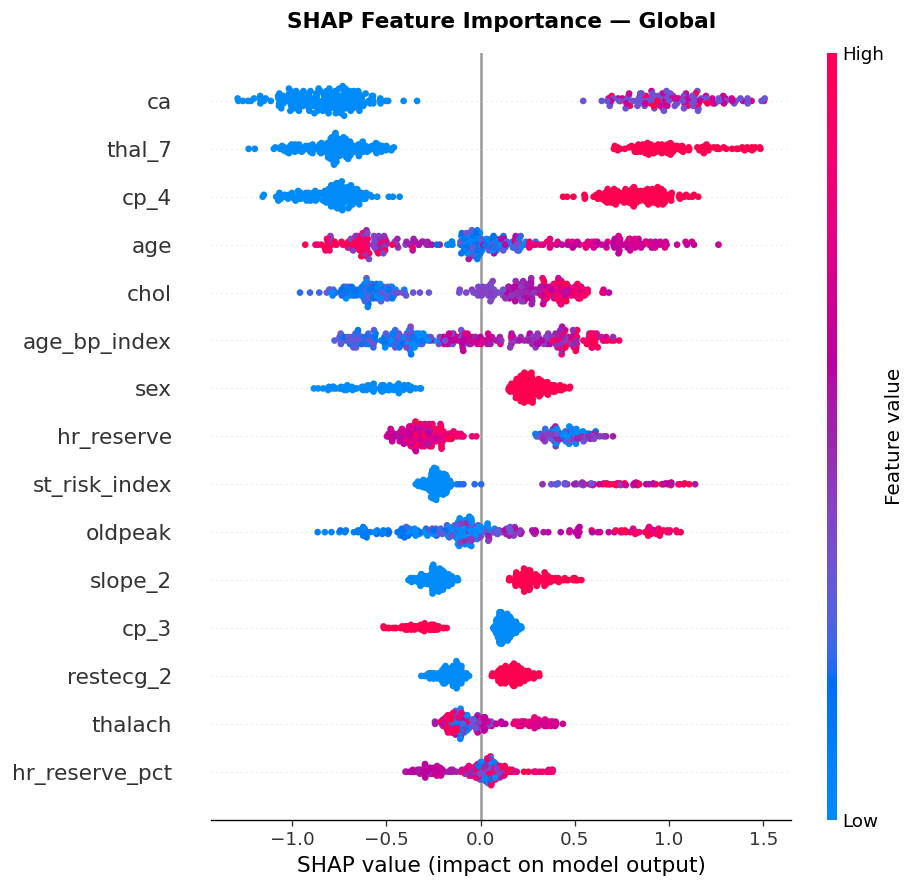

In [4]:
plot_summary(shap_values, X, max_display=15, plot_type='dot')

## 4. Global Feature Importance — Bar Chart

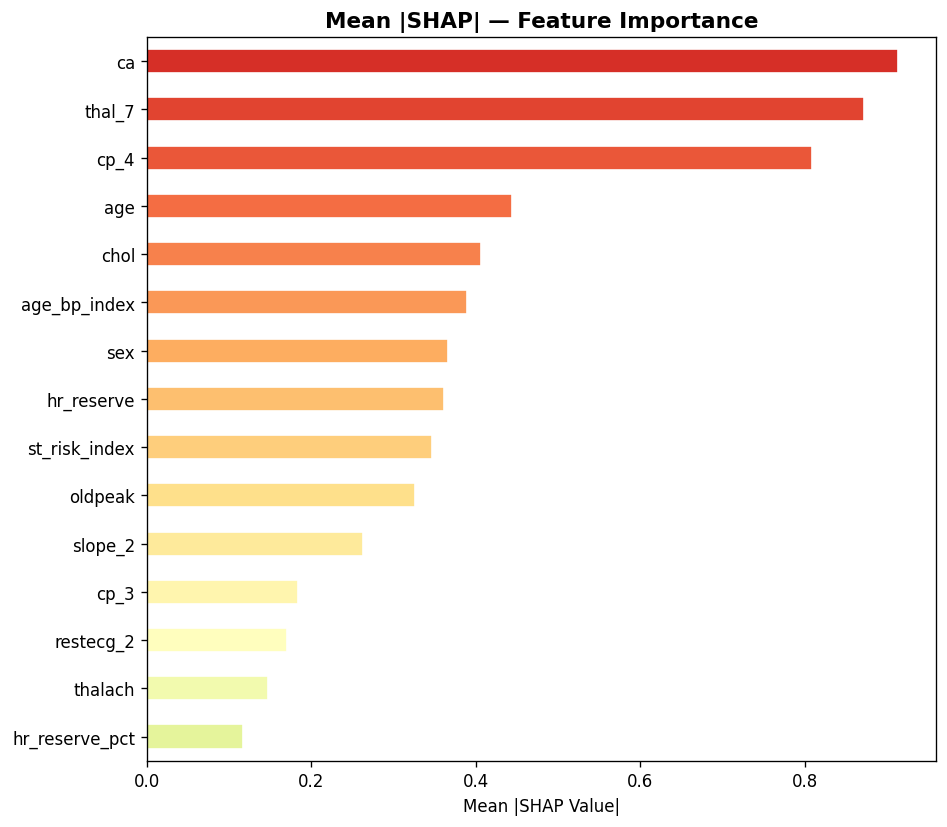

In [5]:
plot_bar(shap_values, X, max_display=15)

## 5. Per-Patient Waterfall — High Risk Patient

Explaining Patient 1  |  Actual: Disease


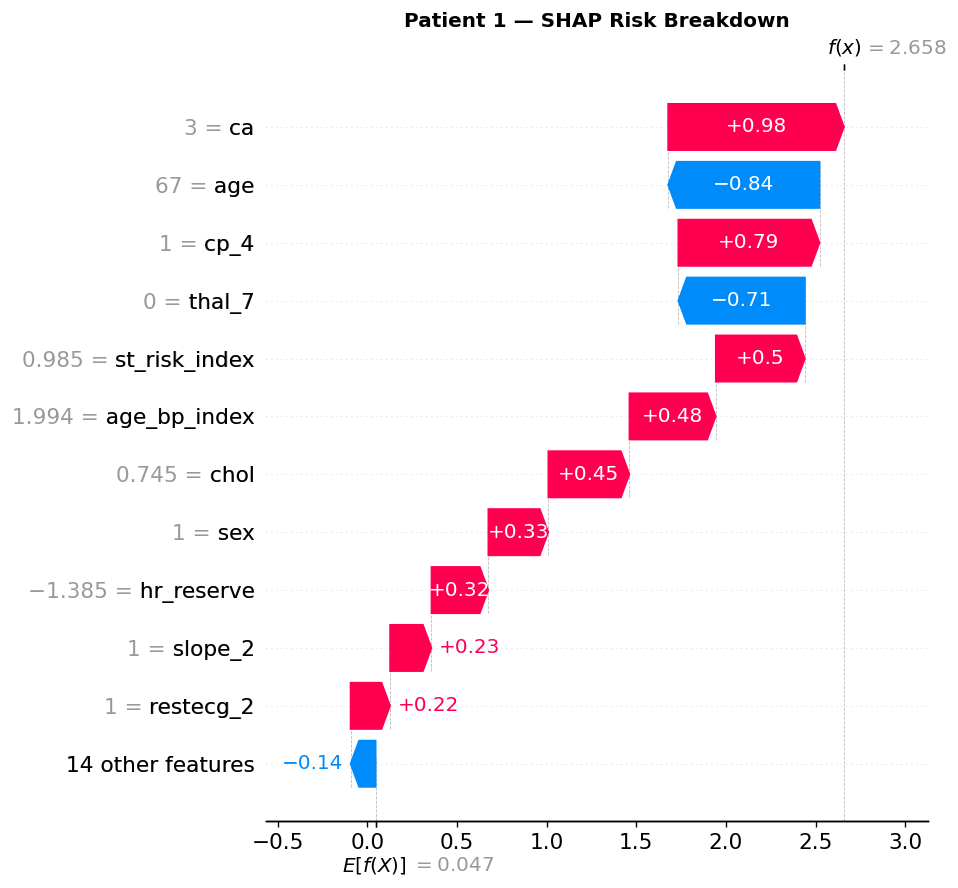

In [6]:
# Pick a confirmed high-risk patient
high_risk_patients = np.where(y == 1)[0]
patient_idx = int(high_risk_patients[0])

print(f'Explaining Patient {patient_idx}  |  Actual: Disease')
plot_waterfall(explainer, X, patient_index=patient_idx, max_display=12)

## 6. Per-Patient Waterfall — Low Risk Patient

Explaining Patient 0  |  Actual: No Disease


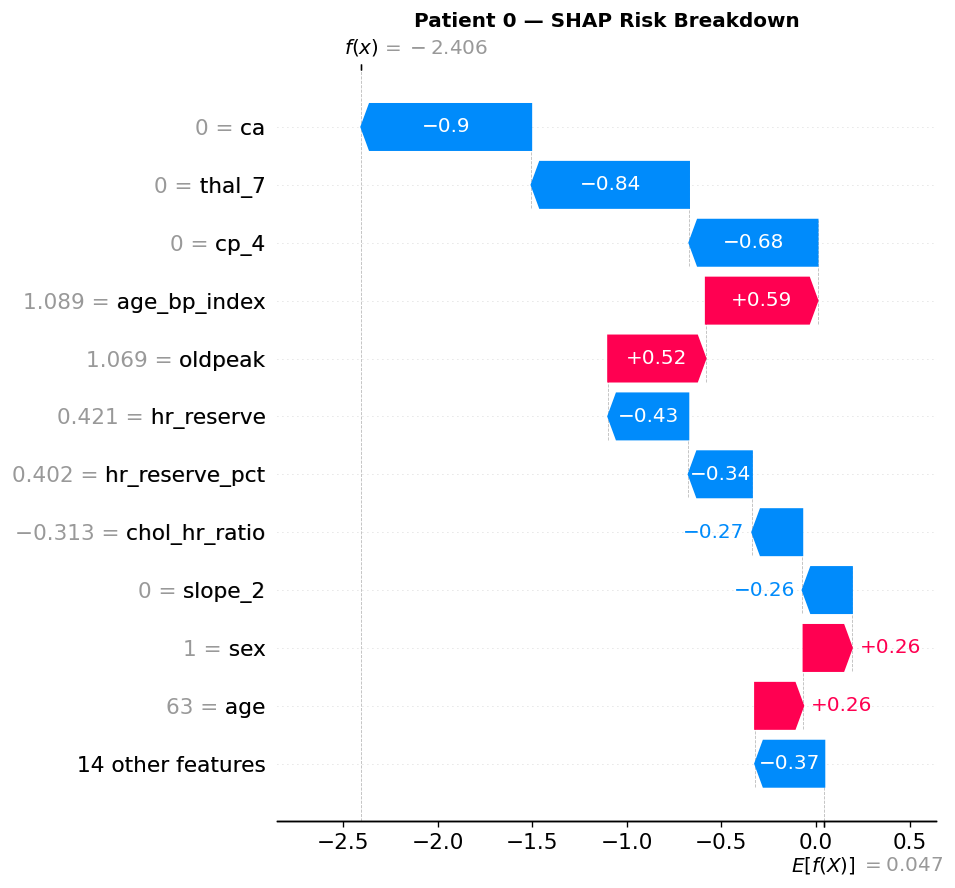

In [7]:
low_risk_patients = np.where(y == 0)[0]
patient_idx_low   = int(low_risk_patients[0])

print(f'Explaining Patient {patient_idx_low}  |  Actual: No Disease')
plot_waterfall(explainer, X, patient_index=patient_idx_low, max_display=12)

## 7. Top Risk Factors — Tabular Explanation

In [8]:
for idx in high_risk_patients[:3]:
    print(f'\n── Patient {idx} (Disease) ──')
    explanation = get_patient_explanation(shap_values, base_value, X, int(idx), top_n=5)
    print(explanation.to_string(index=False))


── Patient 1 (Disease) ──
      feature     value      shap direction
           ca  3.000000  0.980633    ↑ Risk
          age 67.000000 -0.844404    ↓ Risk
         cp_4  1.000000  0.787573    ↑ Risk
       thal_7  0.000000 -0.706073    ↓ Risk
st_risk_index  0.984951  0.497139    ↑ Risk

── Patient 2 (Disease) ──
      feature     value      shap direction
      oldpeak  1.326662  0.913887    ↑ Risk
       thal_7  1.000000  0.892012    ↑ Risk
          age 67.000000 -0.805905    ↓ Risk
         cp_4  1.000000  0.790480    ↑ Risk
st_risk_index  2.071324  0.707030    ↑ Risk

── Patient 6 (Disease) ──
feature    value      shap direction
     ca 2.000000  1.419401    ↑ Risk
   cp_4 1.000000  1.055931    ↑ Risk
 thal_7 0.000000 -0.769790    ↓ Risk
    sex 0.000000 -0.624331    ↓ Risk
oldpeak 2.185652  0.589900    ↑ Risk


## 8. SHAP Dependence Plots — Top 3 Features

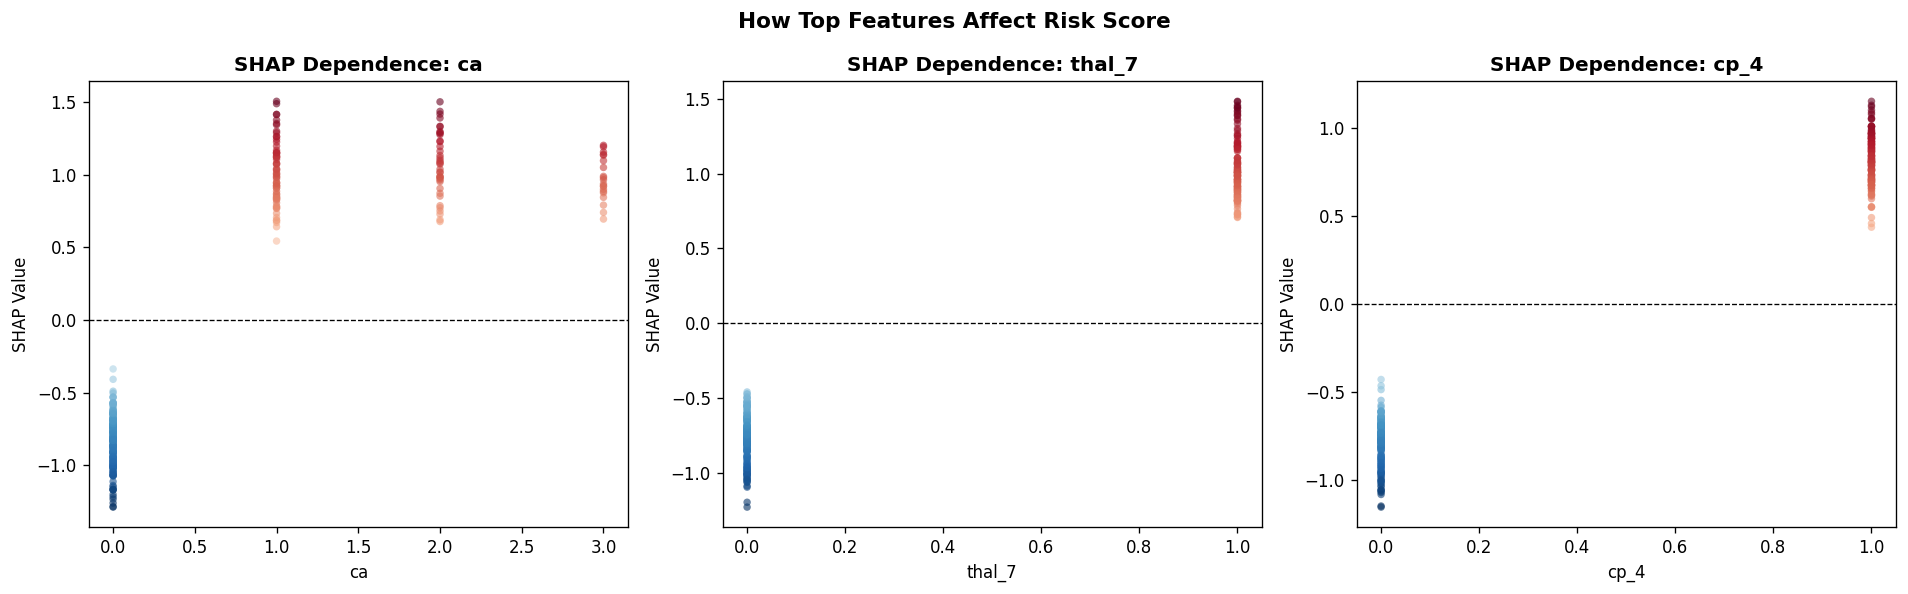

In [9]:
mean_shap   = np.abs(shap_values).mean(axis=0)
top_features = X.columns[np.argsort(mean_shap)[::-1][:3]].tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feat in zip(axes, top_features):
    feat_idx = X.columns.tolist().index(feat)
    ax.scatter(X[feat], shap_values[:, feat_idx],
               c=shap_values[:, feat_idx], cmap='RdBu_r',
               alpha=0.6, s=20, edgecolors='none')
    ax.axhline(0, color='black', lw=0.8, linestyle='--')
    ax.set_xlabel(feat)
    ax.set_ylabel('SHAP Value')
    ax.set_title(f'SHAP Dependence: {feat}', fontweight='bold')

plt.suptitle('How Top Features Affect Risk Score', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary

| Output | Location |
|---|---|
| SHAP values (all patients) | `data/processed/shap_values.npy` |
| Base value | `data/processed/shap_base_value.npy` |
| Global summary | Beeswarm + bar chart above |
| Per-patient | Waterfall plot — loaded in dashboard |

**Key clinical findings:**
- Features with highest global SHAP impact are shown in the bar chart above
- Waterfall plots show exactly which factors are driving each individual patient's risk
- These explanations power the Streamlit dashboard's Explanation page